## CSI5180 - Activity 3 - Fulfillment and Answer Generation

### Learning Objectives

Explore **Fulfillment and Answer Generation** in two different contexts.
* PART A - Weather-related intents
  * Fulfillment through requests to an open-source API (openmeteo)
  * Template-based Answer Generation in Natural Language from JSON reply
* PART B - Mini Treasure Hunt
  * Fulfillment through interactive control of a simulated game
  * Visual display as feedback (+ NL answer for rules/states/issues)



### Team

*   Student A: Fengshou Xu + 300036335
*   Student B: Henry Tan + 300102229

### Submission Information

*   Make sure you follow the steps below and show your work to the TA DURING class time (March 13th). **Attendance/Participation/In-Class work is worth 3% of your activity.**
*   Complete the notebook (see the TODOs) and submit on Brightspace, in the Assignment section, under Activity 3.  **Deadline for final submission is Wednesday March 18th, 11:59pm.** Late submission will be penalized 20% per day.  This is worth 5% of your activity.
* Make sure both members of the team submit, and that your names are both at the top of the notebook.  

###Disclaimer from professor Caroline Barrière

I created this starter notebook with the help of ChatGPT.  Through multiple exchanges, I was able to obtain the starter code that fitted my purpose: to go through all steps for performing fulfillment (skill-based and simulated interactive control) and template-based answer generation.  I am not an expert coder (far from it), and therefore I apologize ahead of time if some of the code is slightly obscur as it is a mix of home-made and AI-generated code.

Do not hesitate to make changes to the code if you find better/simpler ways of doing some operations.

### *PART A - Skill-based Fulfillment with NL answer generation*

The skill we use is **open-meteo API**.  We assume intents/slots are already recognized (intent detection and slot filling has been done) and focus on the fulfillment and answer generation step.

The site https://open-meteo.com/ can be explored to see what they offer.  It is quite a complex site (lots of possibilities), so I am narrowing down to a subset of intents below.

Also, since it is a known API with lots of available documentation, you can also engage with your favorite GenAI tool to get information/examples of how to use it.  This will be helpful for the *TODO* below.

***
***TODO: Expand the notebook***

Go through the full Part A code first... then come back here to add additional intents that can be fulfilled with open-meteo API, perform their fulfillment and the generation of answers.

1.   Add the following intents and 2 more of your choice.  
     - Get apparent (feels like) temperature
     - Get daily forecast (include a slot for which day)
     - Get sunrise/sunset time (include a slot for which day)
     - Get rain probability (include a slot for which day)
2.   Add code to deal with city names that are ambiguous (e.g. Sydney (Nova Scotia, Canada) versus Sydney (Australia)).  It is your choice how to deal with this ambiguity.  You can use defaults for a country slot, or distance to user (asking where they live first), etc.
3.   Expand the weather code mapping. (in step 4a)
4.   Make sure to include at least 3 templates for each intent answer and include code to select one at random.
5.   Test the set of intents with at least 3 cities.

***


***PLEASE NOTE:  During class, please show to the TA the code that you added to include at least one more intent, to deal with ambiguous city names, as well as additional Natural Language Answer templates for that intent.***
***


**Step 1 - Imports**

In [20]:
import requests
import json
import random
from datetime import datetime, timedelta

**Step 2 - GeoCoding**

Sometimes parameters requested by an API necessitate an intermediate call to the API to obtain information.

Here, we require the geocoding of cities into latitude/longitude.

In [21]:
# GeoCoding, uses city name as input and generates latitude, longitude
# Uses IP geolocation to detect user's country as default filter for ambiguous city names

# Cache the user's country so we only call the IP API once
_cached_country = None

def get_user_country():
    global _cached_country
    if _cached_country is not None:
        return _cached_country
    try:
        response = requests.get("https://ipapi.co/json/", timeout=5)
        if response.status_code == 200:
            _cached_country = response.json().get("country_name")
            return _cached_country
    except:
        pass
    # Fallback: default to Canada (since we are in Canada)
    _cached_country = "Canada"
    return _cached_country

def get_coordinates(city, country=None):
    if country is None:
        country = get_user_country()  # IP-based default, cached

    url = "https://geocoding-api.open-meteo.com/v1/search"

    params = {
        "name": city,
        "count": 10  # Return multiple results to filter
    }

    response = requests.get(url, params=params)

    if response.status_code != 200:
        return None

    data = response.json()

    if "results" not in data:
        return None

    results = data["results"]

    # Filter by country if provided
    if country:
        filtered = [r for r in results if country.lower() in r.get("country", "").lower()]
        if filtered:
            results = filtered

    lat = results[0]["latitude"]
    lon = results[0]["longitude"]

    return lat, lon

In [22]:
# This is just for testing --- Exploring the API (JSON dump)
# Useful if you comment out the print statement in the get_coordinates above and change the count
# You will then find many "Sydney"

lat, lon = get_coordinates("Sydney")
print(lat, lon)

46.1351 -60.1831


**Step 3 - Building the Weather API Call**

In [24]:
# The API defines different variables that can be used to obtain different information

CURRENT_VARS = (
    "temperature_2m,"           # Temperature
    "relative_humidity_2m,"     # Humidity
    "apparent_temperature,"     # Feels like temperature
    "precipitation,"            # Precipitation (rain amount)
    "weather_code,"             # Weather condition code
    "wind_speed_10m"            # Wind Speed
)

# Daily variables - returns an array of 7 days (index 0 = today, 1 = tomorrow, etc.)
DAILY_VARS = (
    "temperature_2m_max,"
    "temperature_2m_min,"
    "sunrise,"
    "sunset,"
    "precipitation_probability_max"  # Needed for rain probability intent
)

In [25]:
# API call definition - now includes both current and daily variables

def call_weather_api(lat, lon):

    url = "https://api.open-meteo.com/v1/forecast"

    params = {
        "latitude": lat,
        "longitude": lon,
        "current": CURRENT_VARS,
        "daily": DAILY_VARS,       # Enabled for daily intents
        "timezone": "auto"
    }

    response = requests.get(url, params=params)

    if response.status_code != 200:
        return None

    return response.json()

**Step 4 - Calling the API and retrieving JSON answer**

The code below makes the call to the API, retrieves the JSON and generates an answer.

In [26]:
# This is just for testing --- Exploring the API (JSON dump)

lat, lon = get_coordinates("Ottawa")
data = call_weather_api(lat, lon)
print(json.dumps(data, indent=2))

{
  "latitude": 45.406376,
  "longitude": -75.71817,
  "generationtime_ms": 0.16939640045166016,
  "utc_offset_seconds": -14400,
  "timezone": "America/Toronto",
  "timezone_abbreviation": "GMT-4",
  "elevation": 74.0,
  "current_units": {
    "time": "iso8601",
    "interval": "seconds",
    "temperature_2m": "\u00b0C",
    "relative_humidity_2m": "%",
    "apparent_temperature": "\u00b0C",
    "precipitation": "mm",
    "weather_code": "wmo code",
    "wind_speed_10m": "km/h"
  },
  "current": {
    "time": "2026-03-18T16:45",
    "interval": 900,
    "temperature_2m": -3.6,
    "relative_humidity_2m": 57,
    "apparent_temperature": -8.0,
    "precipitation": 0.0,
    "weather_code": 3,
    "wind_speed_10m": 7.9
  },
  "daily_units": {
    "time": "iso8601",
    "temperature_2m_max": "\u00b0C",
    "temperature_2m_min": "\u00b0C",
    "sunrise": "iso8601",
    "sunset": "iso8601",
    "precipitation_probability_max": "%"
  },
  "daily": {
    "time": [
      "2026-03-18",
      "202

*Step 4a - Extracting required information from JSON*

In [27]:
def extract_weather_info(data):
    current = data["current"]
    return {
        "temperature": current["temperature_2m"],
        "windspeed": current["wind_speed_10m"],
        "weathercode": current["weather_code"],
        "precipitation": current["precipitation"],
        "relative_humidity": current["relative_humidity_2m"],
        "time": current["time"]
    }

def extract_feels_like_info(data):
    current = data["current"]
    return {
        "apparent_temperature": current["apparent_temperature"],
        "temperature": current["temperature_2m"],
        "time": current["time"]
    }

def extract_daily_forecast_info(data, day=0):
    daily = data["daily"]
    return {
        "date": daily["time"][day],
        "temp_max": daily["temperature_2m_max"][day],
        "temp_min": daily["temperature_2m_min"][day],
    }

def extract_sunrise_sunset_info(data, day=0):
    daily = data["daily"]
    return {
        "date": daily["time"][day],
        "sunrise": daily["sunrise"][day],
        "sunset": daily["sunset"][day],
    }

def extract_rain_probability_info(data, day=0):
    daily = data["daily"]
    return {
        "date": daily["time"][day],
        "rain_probability": daily["precipitation_probability_max"][day],
    }

def extract_humidity_info(data):
    current = data["current"]
    return {
        "relative_humidity": current["relative_humidity_2m"],
        "temperature": current["temperature_2m"],
        "time": current["time"]
    }

def extract_wind_info(data):
    current = data["current"]
    return {
        "wind_speed": current["wind_speed_10m"],
        "temperature": current["temperature_2m"],
        "time": current["time"]
    }

In [28]:
weather_code_map = {
    0: "clear sky",
    1: "mainly clear",
    2: "partly cloudy",
    3: "overcast",
    45: "fog",
    48: "depositing rime fog",
    51: "light drizzle",
    53: "moderate drizzle",
    55: "dense drizzle",
    56: "light freezing drizzle",
    57: "dense freezing drizzle",
    61: "slight rain",
    63: "moderate rain",
    65: "heavy rain",
    66: "light freezing rain",
    67: "heavy freezing rain",
    71: "slight snow fall",
    73: "moderate snow fall",
    75: "heavy snow fall",
    77: "snow grains",
    80: "slight rain showers",
    81: "moderate rain showers",
    82: "violent rain showers",
    85: "slight snow showers",
    86: "heavy snow showers",
    95: "thunderstorm",
    96: "thunderstorm with slight hail",
    99: "thunderstorm with heavy hail",
}

*Step 4b - Natural Language Generation*

In [29]:
def day_label(day_index):
    if day_index == 0:
        return "today"
    elif day_index == 1:
        return "tomorrow"
    else:
        target = datetime.now().date() + timedelta(days=day_index)
        return target.strftime("%A, %B %d")


def generate_weather_answer(city, info):
    description = weather_code_map.get(info["weathercode"], "unknown conditions")
    templates = [
        (
            f"The current weather in {city} is {description}. "
            f"The temperature is {info['temperature']}\u00b0C "
            f"with wind speed of {info['windspeed']} km/h."
        ),
        (
            f"Right now in {city}, it's {info['temperature']}\u00b0C with {description}. "
            f"Wind is blowing at {info['windspeed']} km/h."
        ),
        (
            f"In {city}, expect {description} at {info['temperature']}\u00b0C. "
            f"Current wind speed is {info['windspeed']} km/h."
        ),
    ]
    return random.choice(templates)


def generate_feels_like_answer(city, info):
    templates = [
        (
            f"In {city}, the temperature is {info['temperature']}\u00b0C "
            f"but it feels like {info['apparent_temperature']}\u00b0C."
        ),
        (
            f"It's {info['temperature']}\u00b0C in {city}, "
            f"though the apparent temperature is {info['apparent_temperature']}\u00b0C."
        ),
        (
            f"The feels-like temperature in {city} is {info['apparent_temperature']}\u00b0C, "
            f"while the actual reading is {info['temperature']}\u00b0C."
        ),
    ]
    return random.choice(templates)


def generate_daily_forecast_answer(city, info, day=0):
    label = day_label(day)
    templates = [
        (
            f"The forecast for {city} {label} shows a high of {info['temp_max']}\u00b0C "
            f"and a low of {info['temp_min']}\u00b0C."
        ),
        (
            f"In {city} {label}, temperatures will range "
            f"from {info['temp_min']}\u00b0C to {info['temp_max']}\u00b0C."
        ),
        (
            f"Expect highs of {info['temp_max']}\u00b0C and lows of "
            f"{info['temp_min']}\u00b0C in {city} {label}."
        ),
    ]
    return random.choice(templates)


def generate_sunrise_sunset_answer(city, info, day=0):
    label = day_label(day)
    sunrise_time = info["sunrise"].split("T")[1]
    sunset_time = info["sunset"].split("T")[1]
    templates = [
        f"In {city} {label}, the sun rises at {sunrise_time} and sets at {sunset_time}.",
        f"Sunrise in {city} {label} is at {sunrise_time}, with sunset at {sunset_time}.",
        f"For {city} {label}: sunrise at {sunrise_time}, sunset at {sunset_time}.",
    ]
    return random.choice(templates)


def generate_rain_probability_answer(city, info, day=0):
    label = day_label(day)
    templates = [
        f"The chance of rain in {city} {label} is {info['rain_probability']}%.",
        f"There is a {info['rain_probability']}% probability of rain in {city} {label}.",
        f"Rain probability for {city} {label} stands at {info['rain_probability']}%.",
    ]
    return random.choice(templates)


def generate_humidity_answer(city, info):
    templates = [
        (
            f"The current humidity in {city} is {info['relative_humidity']}% "
            f"with a temperature of {info['temperature']}\u00b0C."
        ),
        (
            f"In {city} right now, relative humidity is at {info['relative_humidity']}% "
            f"and the temperature is {info['temperature']}\u00b0C."
        ),
        (
            f"Humidity in {city} is currently {info['relative_humidity']}%. "
            f"The temperature reads {info['temperature']}\u00b0C."
        ),
    ]
    return random.choice(templates)


def generate_wind_answer(city, info):
    templates = [
        (
            f"Wind speed in {city} is currently {info['wind_speed']} km/h "
            f"with a temperature of {info['temperature']}\u00b0C."
        ),
        (
            f"In {city}, the wind is blowing at {info['wind_speed']} km/h right now. "
            f"Temperature is {info['temperature']}\u00b0C."
        ),
        (
            f"Current wind conditions in {city}: {info['wind_speed']} km/h. "
            f"The temperature is {info['temperature']}\u00b0C."
        ),
    ]
    return random.choice(templates)

**Step 5 - Full pipeline**

The code above will be used within the pipeline which starts from an intent, fulfills it and generates the answer.

In [30]:
def fulfill_intent(request):

    intent = request["intent"]
    city = request["slots"]["city"]
    country = request["slots"].get("country")
    day = request["slots"].get("day", 0)

    coords = get_coordinates(city, country)

    if coords is None:
        return "Sorry, I could not find that city."

    lat, lon = coords
    weather_data = call_weather_api(lat, lon)

    if weather_data is None:
        return "Sorry, I could not retrieve the weather data."

    if intent == "get_weather":
        info = extract_weather_info(weather_data)
        return generate_weather_answer(city, info)

    elif intent == "get_feels_like":
        info = extract_feels_like_info(weather_data)
        return generate_feels_like_answer(city, info)

    elif intent == "get_daily_forecast":
        info = extract_daily_forecast_info(weather_data, day)
        return generate_daily_forecast_answer(city, info, day)

    elif intent == "get_sunrise_sunset":
        info = extract_sunrise_sunset_info(weather_data, day)
        return generate_sunrise_sunset_answer(city, info, day)

    elif intent == "get_rain_probability":
        info = extract_rain_probability_info(weather_data, day)
        return generate_rain_probability_answer(city, info, day)

    elif intent == "get_humidity":
        info = extract_humidity_info(weather_data)
        return generate_humidity_answer(city, info)

    elif intent == "get_wind":
        info = extract_wind_info(weather_data)
        return generate_wind_answer(city, info)

    else:
        return f"Unknown intent: {intent}"

In [35]:
test_requests = [
    {"intent": "get_weather", "slots": {"city": "Ottawa"}},
    {"intent": "get_weather", "slots": {"city": "Sydney"}},
    {"intent": "get_weather", "slots": {"city": "Sydney", "country": "Australia"}},
    {"intent": "get_weather", "slots": {"city": "Toronto"}},

    {"intent": "get_feels_like", "slots": {"city": "Ottawa"}},
    {"intent": "get_feels_like", "slots": {"city": "Sydney"}},
    {"intent": "get_feels_like", "slots": {"city": "Toronto"}},

    {"intent": "get_daily_forecast", "slots": {"city": "Ottawa", "day": 0}},
    {"intent": "get_daily_forecast", "slots": {"city": "Sydney", "day": 1}},
    {"intent": "get_daily_forecast", "slots": {"city": "Toronto", "day": 2}},

    {"intent": "get_sunrise_sunset", "slots": {"city": "Ottawa", "day": 0}},
    {"intent": "get_sunrise_sunset", "slots": {"city": "Sydney", "day": 1}},
    {"intent": "get_sunrise_sunset", "slots": {"city": "Toronto", "day": 0}},

    {"intent": "get_rain_probability", "slots": {"city": "Ottawa", "day": 1}},
    {"intent": "get_rain_probability", "slots": {"city": "Sydney", "day": 0}},
    {"intent": "get_rain_probability", "slots": {"city": "Toronto", "day": 2}},

    {"intent": "get_humidity", "slots": {"city": "Ottawa"}},
    {"intent": "get_humidity", "slots": {"city": "Sydney"}},
    {"intent": "get_humidity", "slots": {"city": "Toronto"}},

    {"intent": "get_wind", "slots": {"city": "Ottawa"}},
    {"intent": "get_wind", "slots": {"city": "Sydney"}},
    {"intent": "get_wind", "slots": {"city": "Toronto"}},
]

# for req in test_requests:
#     print(f"[{req['intent']}] {req['slots']}")
#     print(f"  -> {fulfill_intent(req)}")
#     print()
for req in test_requests:
     intent_name = req['intent']
     slots = req['slots']
     result = fulfill_intent(req)
     print(f"[{intent_name}] {slots}")
     print(f"  -> {result}")

[get_weather] {'city': 'Ottawa'}
  -> In Ottawa, expect overcast at -3.7°C. Current wind speed is 8.9 km/h.
[get_weather] {'city': 'Sydney'}
  -> In Sydney, expect partly cloudy at -4.2°C. Current wind speed is 17.1 km/h.
[get_weather] {'city': 'Sydney', 'country': 'Australia'}
  -> Right now in Sydney, it's 20.0°C with overcast. Wind is blowing at 1.5 km/h.
[get_weather] {'city': 'Toronto'}
  -> Right now in Toronto, it's -1.8°C with overcast. Wind is blowing at 16.6 km/h.
[get_feels_like] {'city': 'Ottawa'}
  -> It's -3.7°C in Ottawa, though the apparent temperature is -8.3°C.
[get_feels_like] {'city': 'Sydney'}
  -> It's -4.2°C in Sydney, though the apparent temperature is -10.1°C.
[get_feels_like] {'city': 'Toronto'}
  -> It's -1.8°C in Toronto, though the apparent temperature is -7.4°C.
[get_daily_forecast] {'city': 'Ottawa', 'day': 0}
  -> The forecast for Ottawa today shows a high of -3.8°C and a low of -18.4°C.
[get_daily_forecast] {'city': 'Sydney', 'day': 1}
  -> Expect highs

### *PART B - Interactive Control System*

The second part of this notebook is to explore intent fulfillment but within a control system where NL answers are additional to a visual display. In the mini-game you will explore below, NL sentences are useful to tell the character what is possible or not.

The mini-game is a treasure hunt.  In its **current setting**, to get to the treasure, the character must:
- open the door of room 1
- enter a first room
- search for a key under the chair
- open the door of room 2
- enter the second room
- open the chest with the key

You will see the code that draws the rooms, as well as guide the character as to what is happening.  For example, if the character wishes to open a room and the door is closed, the system would inform that the door must first be open.

***
***TODO: Expand the notebook***

Go through the full Part B code first... then modify the notebook to expand the game to:

1. Add an intent "get help" (or "what can I do?") to tell the user what is possible in the game.
2. Add a chair in room 2 and a chest in room 1.
3. There can now be 4 different combinations (4 games):
    - key under chair 1, treasure in chest 2
    - key under chair 1, treasure in chest 1
    - key under chair 2, treasure in chest 1
    - key under chair 2, treasure in chest 2
4. Adapt the game state (see suggestion below), the set of intents, the fulfillment and state logic to the extended version.
5. Show a scenario (character playing).

***

**Step 1 - Define the state**

Think of how to define the state of the game.

#### Implementation Details — Expanded Game

**Redesign of the Game State**

The original game state is hard-coded, especially the "key_found" variable is tied to room1.

To support the expanded game with two rooms, we changed the logic massively.

We created `create_game_state` to initialize/reinitialize the game state based on a randomly selected configuration. The state now includes a symmetric structure for each room:

```
room1/room2: { door_open, chair_has_key, chest_open, chest_has_treasure }
```

An `inventory` list replaces the `key_found` boolean, which is a more extendable design.

**4 Game Configurations**

On start/restart, one of 4 configurations will be randomly selected via `random.choice(GAME_CONFIGS)`:

| Config | Key location | Treasure location |
|--------|-------------|-------------------|
| 1 | Room 1 chair | Room 2 chest |
| 2 | Room 1 chair | Room 1 chest |
| 3 | Room 2 chair | Room 1 chest |
| 4 | Room 2 chair | Room 2 chest |

**New and Modified Intents**

| Intent | Change                                                                                                                                                                 |
|--------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `get_help` | **New.** Lists available actions based on player's current position and inventory. Does not change state.                                                              |
| `search chair` | **Modified.** Now works in both rooms. Checks `chair_has_key` of the current room instead of only room1. Adds "key" to inventory if found.                             |
| `open chest` | **Modified.** Now works in both rooms. Checks the current room's chest. Reports treasure or empty. Key stays in inventory after use so the player can try both chests. |
| `restart` | **Modified.** Randomly selects a configuration. Prints which room has the key and treasure.                                                                            |
| `open door1/door2`, `enter room1/room2` | Logic remain unchanged , minor message updates.                                                                                                                        |

**Visual Display Changes**

- Both rooms now draw a chair (brown rectangle) and a chest (gray/gold rectangle).
- Opened chests show a red star with "Treasure!" or gray "Empty" text.
- Inventory is displayed at the bottom of the figure.
- A yellow dot appears next to the character when holding the key. (even after opening the chest)

In [36]:
GAME_CONFIGS = [
    {"r1_key": True,  "r1_treasure": False, "r2_key": False, "r2_treasure": True},
    {"r1_key": True,  "r1_treasure": True,  "r2_key": False, "r2_treasure": False},
    {"r1_key": False, "r1_treasure": True,  "r2_key": True,  "r2_treasure": False},
    {"r1_key": False, "r1_treasure": False, "r2_key": True,  "r2_treasure": True},
]

def create_game_state(config=None):
    if config is None:
        config = random.choice(GAME_CONFIGS)
    return {
        "room1": {
            "door_open": False,
            "chair_has_key": config["r1_key"],
            "chest_open": False,
            "chest_has_treasure": config["r1_treasure"]
        },
        "room2": {
            "door_open": False,
            "chair_has_key": config["r2_key"],
            "chest_open": False,
            "chest_has_treasure": config["r2_treasure"]
        },
        "character_position": "outside",
        "inventory": []
    }

game_state = create_game_state(GAME_CONFIGS[0])

**Step 2 - Define a visual display**

As the feedback to the user will be partially with a visual display, it must be defined.

In [37]:
import matplotlib.pyplot as plt

def draw_room(state):

    _, ax = plt.subplots(figsize=(10, 7))

    ax.add_patch(plt.Rectangle((0, 0), 5, 6, fill=False, linewidth=2))
    ax.text(2.5, 6.3, "Room 1", ha="center", fontsize=12, fontweight="bold")

    door_color1 = "green" if state["room1"]["door_open"] else "red"
    ax.add_patch(plt.Rectangle((2, -0.3), 1, 0.5, color=door_color1))
    ax.text(2.5, 0.4, "Door1", ha="center", fontsize=8)

    ax.add_patch(plt.Rectangle((0.5, 4), 1.5, 1.5, color="brown"))
    ax.text(1.25, 5.7, "Chair", ha="center", fontsize=8)

    chest_color1 = "gold" if state["room1"]["chest_open"] else "gray"
    ax.add_patch(plt.Rectangle((3, 4), 1.5, 1.5, color=chest_color1))
    ax.text(3.75, 5.7, "Chest", ha="center", fontsize=8)

    if state["room1"]["chest_open"] and state["room1"]["chest_has_treasure"]:
        ax.plot(3.75, 4.75, "r*", markersize=20)
        ax.text(3.75, 4.1, "Treasure!", ha="center", fontsize=8, color="red")

    if state["room1"]["chest_open"] and not state["room1"]["chest_has_treasure"]:
        ax.text(3.75, 4.75, "Empty", ha="center", fontsize=8, color="dimgray")

    ax.add_patch(plt.Rectangle((6, 0), 5, 6, fill=False, linewidth=2))
    ax.text(8.5, 6.3, "Room 2", ha="center", fontsize=12, fontweight="bold")

    door_color2 = "green" if state["room2"]["door_open"] else "red"
    ax.add_patch(plt.Rectangle((5, 2.5), 1, 1, color=door_color2))
    ax.text(5.5, 3.7, "Door2", ha="center", fontsize=8, rotation=90)

    ax.add_patch(plt.Rectangle((6.5, 4), 1.5, 1.5, color="brown"))
    ax.text(7.25, 5.7, "Chair", ha="center", fontsize=8)

    chest_color2 = "gold" if state["room2"]["chest_open"] else "gray"
    ax.add_patch(plt.Rectangle((9, 4), 1.5, 1.5, color=chest_color2))
    ax.text(9.75, 5.7, "Chest", ha="center", fontsize=8)

    if state["room2"]["chest_open"] and state["room2"]["chest_has_treasure"]:
        ax.plot(9.75, 4.75, "r*", markersize=20)
        ax.text(9.75, 4.1, "Treasure!", ha="center", fontsize=8, color="red")

    if state["room2"]["chest_open"] and not state["room2"]["chest_has_treasure"]:
        ax.text(9.75, 4.75, "Empty", ha="center", fontsize=8, color="dimgray")

    if state["character_position"] == "outside":
        char_x, char_y = 2.5, -1.5
    elif state["character_position"] == "room1":
        char_x, char_y = 2.5, 2
    elif state["character_position"] == "room2":
        char_x, char_y = 8.5, 2

    ax.plot(char_x, char_y, "bo", markersize=14)
    ax.text(char_x, char_y + 0.5, "You", ha="center", fontsize=10)

    if "key" in state["inventory"]:
        ax.plot(char_x + 0.4, char_y + 0.2, "yo", markersize=8)

    inv = state["inventory"]
    inv_str = ", ".join(inv) if inv else "empty"
    ax.text(0, -1.8, f"Inventory: {inv_str}", fontsize=10)

    ax.set_xlim(-1, 12)
    ax.set_ylim(-2.5, 7.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()

**Step 3 - Fulfillment**

Once an intent is provided, it must be fulfilled.

In [38]:
def fulfill_intent(intent):
    action = intent["intent"]
    slots = intent.get("slots", {})

    global game_state

    if action == "restart":
        game_state = create_game_state()
        key_room = "Room1" if game_state["room1"]["chair_has_key"] else "Room2"
        treasure_room = "Room1" if game_state["room1"]["chest_has_treasure"] else "Room2"
        return (
            f"Game restarted! Key hidden in {key_room}, "
            f"Treasure hidden in {treasure_room}."
        ), True

    if action == "get_help":
        pos = game_state["character_position"]
        actions = []
        if pos == "outside":
            if not game_state["room1"]["door_open"]:
                actions.append("open door1")
            actions.append("enter room1 (if door1 is open)")
        elif pos == "room1":
            actions.append("search chair")
            if not game_state["room1"]["chest_open"]:
                actions.append("open chest (requires key)")
            if not game_state["room2"]["door_open"]:
                actions.append("open door2")
            actions.append("enter room2 (if door2 is open)")
        elif pos == "room2":
            actions.append("search chair")
            if not game_state["room2"]["chest_open"]:
                actions.append("open chest (requires key)")
            actions.append("enter room1")
        inv = game_state["inventory"]
        inv_str = ", ".join(inv) if inv else "nothing"
        return (
            f"You are {pos}. Inventory: {inv_str}. "
            f"Possible actions: {'; '.join(actions)}."
        ), False

    if action == "open":
        obj = slots.get("object")
        tool = slots.get("tool")

        if obj == "door1":
            if game_state["room1"]["door_open"]:
                return "Door1 is already open.", False
            game_state["room1"]["door_open"] = True
            return "You opened Door1.", True

        if obj == "door2":
            if game_state["character_position"] != "room1":
                return "You must be in Room1 to open Door2.", False
            if game_state["room2"]["door_open"]:
                return "Door2 is already open.", False
            game_state["room2"]["door_open"] = True
            return "You opened Door2.", True

        if obj == "chest":
            pos = game_state["character_position"]
            if pos not in ("room1", "room2"):
                return "You must be in a room to open a chest.", False
            if tool != "key":
                return "You need a key to open the chest.", False
            if "key" not in game_state["inventory"]:
                return "You don't have the key yet.", False
            room = game_state[pos]
            if room["chest_open"]:
                return f"The chest in {pos.capitalize()} is already open.", False
            room["chest_open"] = True
            if room["chest_has_treasure"]:
                return f"You opened the chest in {pos.capitalize()} and found the treasure!", True
            else:
                return f"You opened the chest in {pos.capitalize()}, but it is empty.", True

        return f"You cannot open {obj}.", False

    if action == "enter":
        target = slots.get("room")
        if target == "room1":
            if not game_state["room1"]["door_open"]:
                return "Door1 is closed. Open it first.", False
            game_state["character_position"] = "room1"
            return "You entered Room1.", True
        if target == "room2":
            if not game_state["room2"]["door_open"]:
                return "Door2 is closed. Open it first.", False
            game_state["character_position"] = "room2"
            return "You entered Room2.", True
        return "Unknown room.", False

    if action == "search":
        obj = slots.get("object")
        pos = game_state["character_position"]
        if pos not in ("room1", "room2"):
            return "You are not in a room.", False
        if obj == "chair":
            room = game_state[pos]
            if room["chair_has_key"]:
                room["chair_has_key"] = False
                game_state["inventory"].append("key")
                return f"You found a key under the chair in {pos.capitalize()}!", True
            else:
                return f"You search the chair in {pos.capitalize()} but find nothing.", False
        return f"You search the {obj} but find nothing.", False

    return "Nothing happens.", False

**Step 4 - Manage display after fulfilment**

When a state changes, the visual display is useful.  If there are no changes, it can just remain.  And, Natural Language generation is useful to display messages as to what has been accomplished, or what could not be accomplished.

In [39]:
def run_intent(intent):
    message, changed = fulfill_intent(intent)
    print(message)
    if changed:
        draw_room(game_state)

**Step 5 - Play the game**

The expanded game now has a chair and a chest in each room. On restart, one of 4 configurations is randomly chosen:
1. Key under chair in Room 1, Treasure in chest in Room 2
2. Key under chair in Room 1, Treasure in chest in Room 1
3. Key under chair in Room 2, Treasure in chest in Room 1
4. Key under chair in Room 2, Treasure in chest in Room 2

The demo below uses **Config 3** (key in Room 2, treasure in Room 1) to show a scenario where the player must explore both rooms.

Demo scenario: key hidden under chair in Room2, treasure in chest in Room1


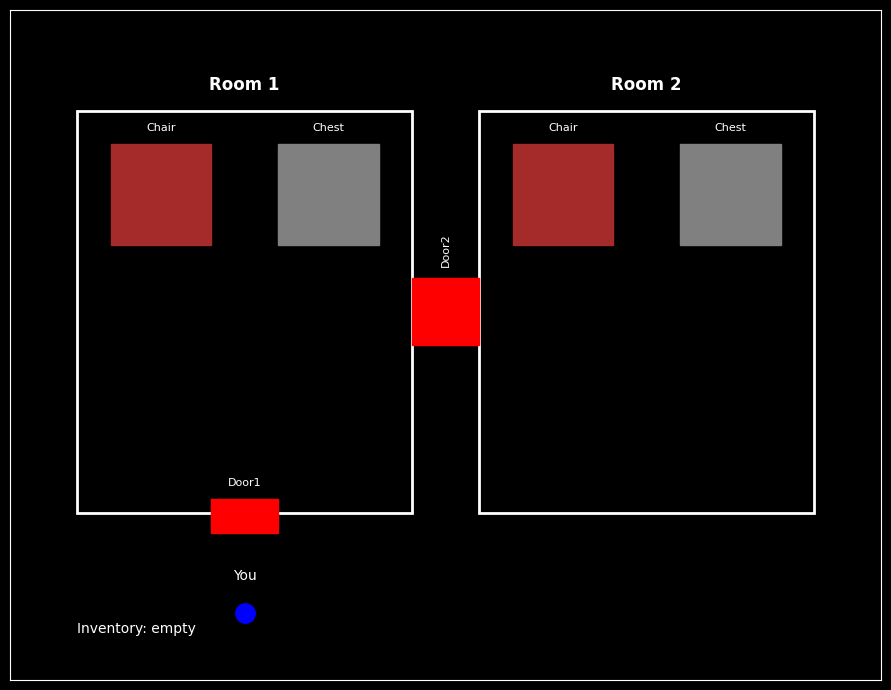

In [40]:
game_state = create_game_state(GAME_CONFIGS[2])
print("Demo scenario: key hidden under chair in Room2, treasure in chest in Room1")
draw_room(game_state)

In [41]:
run_intent({"intent": "get_help"})

You are outside. Inventory: nothing. Possible actions: open door1; enter room1 (if door1 is open).


You opened Door1.


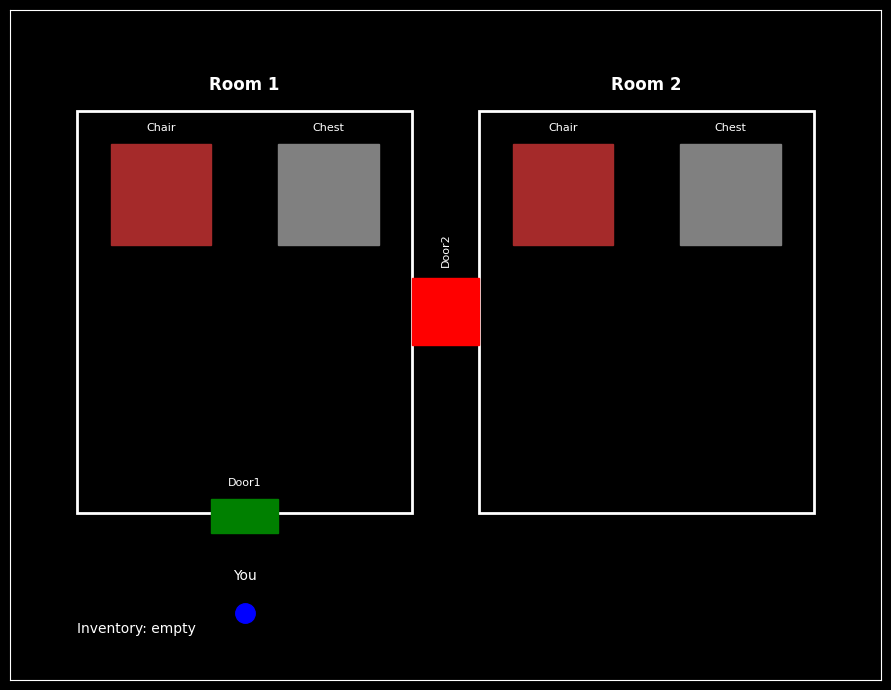

In [42]:
run_intent({"intent": "open", "slots": {"object": "door1"}})

You entered Room1.


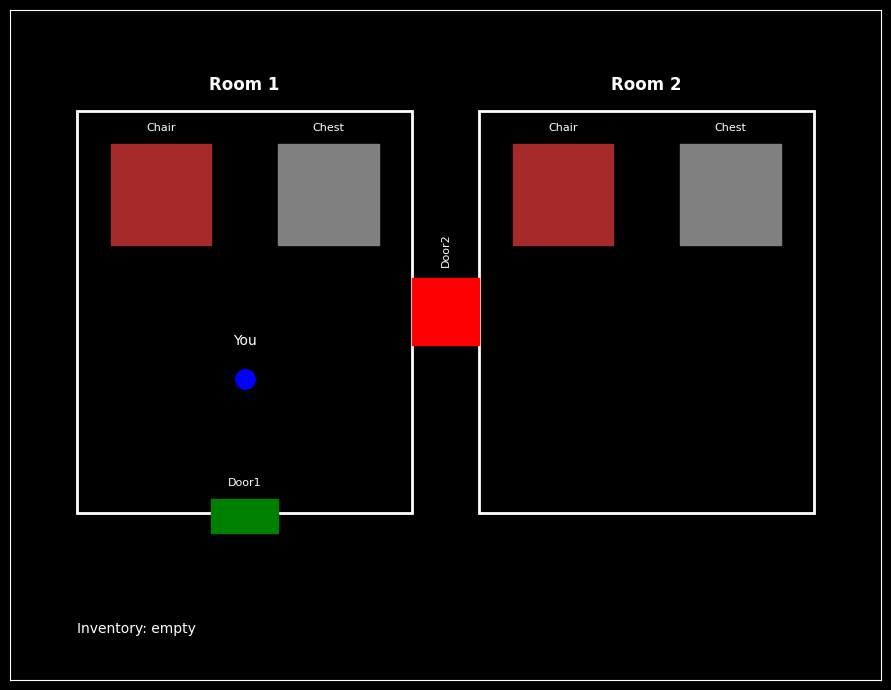

In [43]:
run_intent({"intent": "enter", "slots": {"room": "room1"}})

In [44]:
run_intent({"intent": "search", "slots": {"object": "chair"}})

You search the chair in Room1 but find nothing.


You opened Door2.


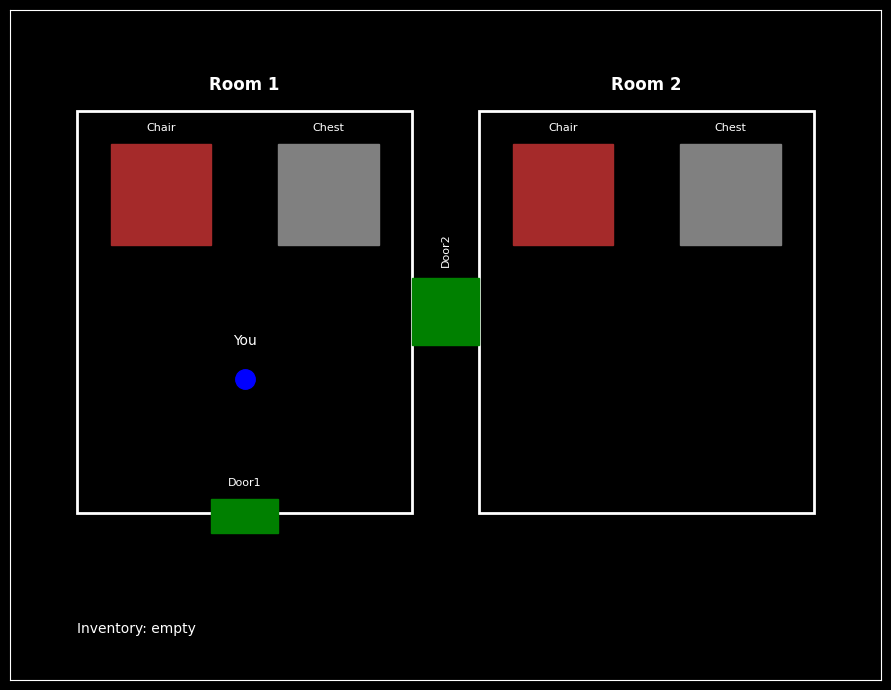

In [45]:
run_intent({"intent": "open", "slots": {"object": "door2"}})

You entered Room2.


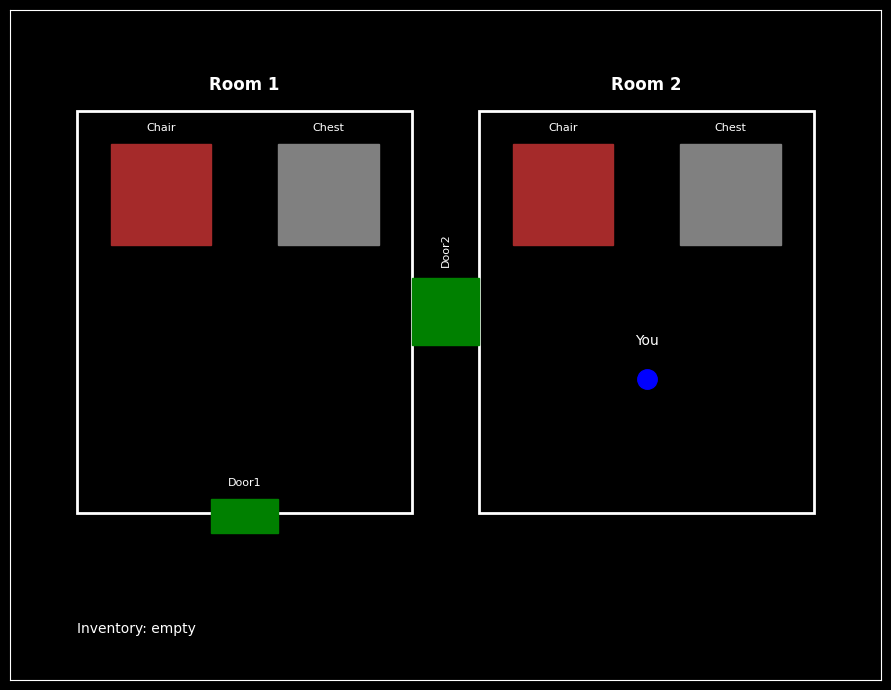

In [46]:
run_intent({"intent": "enter", "slots": {"room": "room2"}})

You found a key under the chair in Room2!


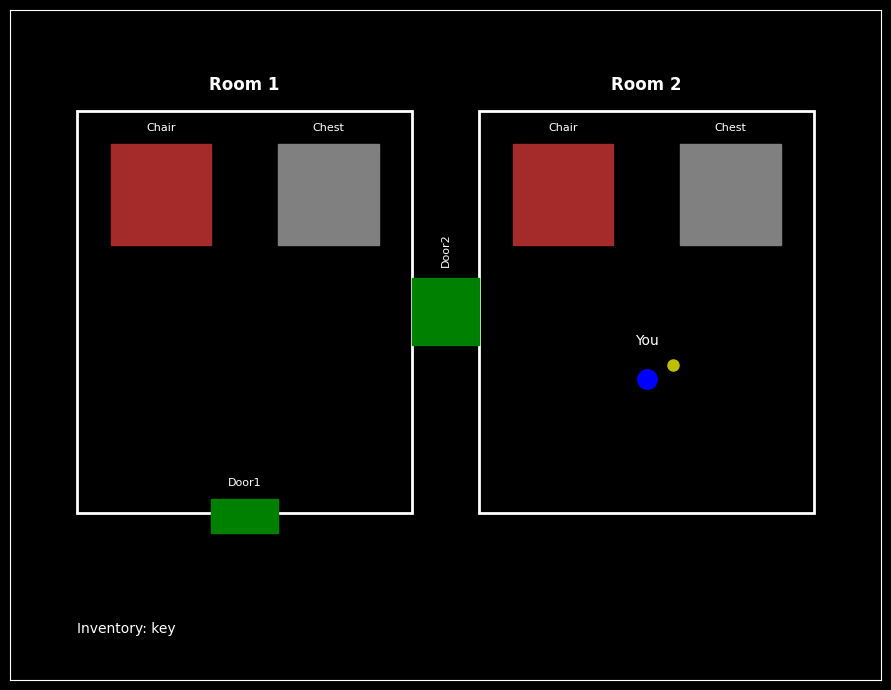

In [47]:
run_intent({"intent": "search", "slots": {"object": "chair"}})

You opened the chest in Room2, but it is empty.


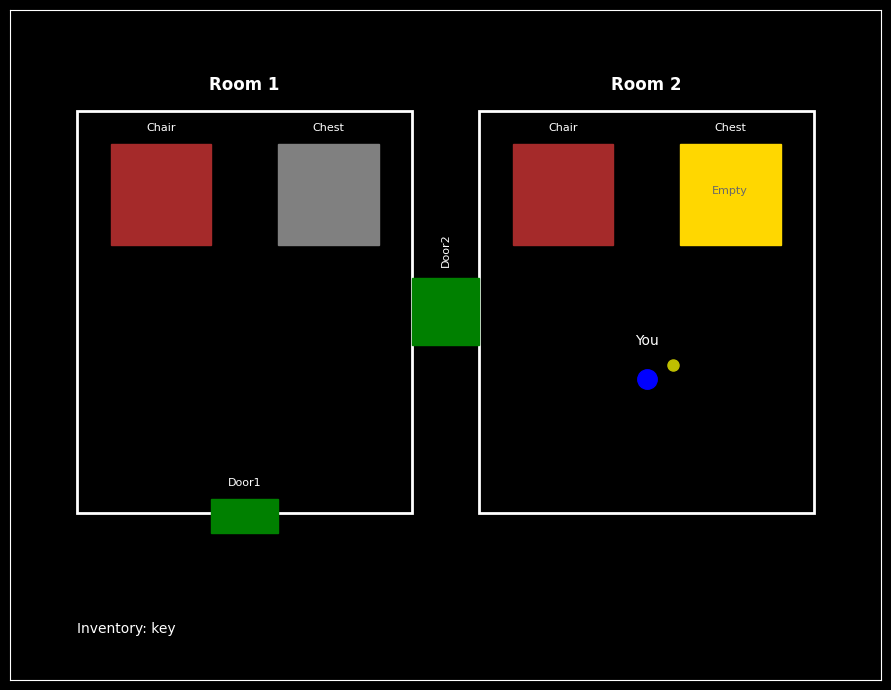

In [48]:
run_intent({"intent": "open", "slots": {"object": "chest", "tool": "key"}})

In [49]:
run_intent({"intent": "get_help"})

You are room2. Inventory: key. Possible actions: search chair; enter room1.


You entered Room1.


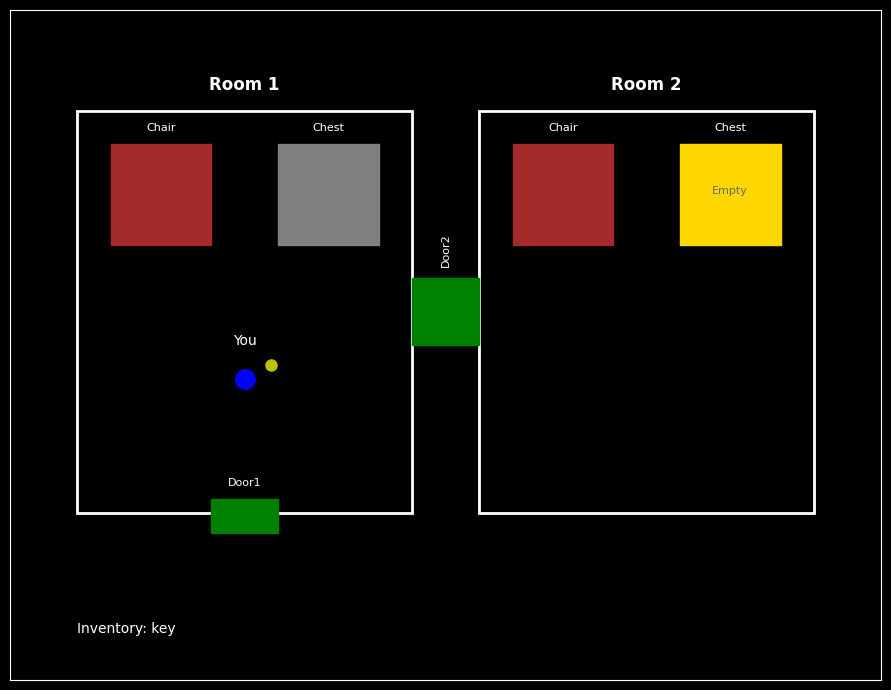

In [50]:
run_intent({"intent": "enter", "slots": {"room": "room1"}})

You opened the chest in Room1 and found the treasure!


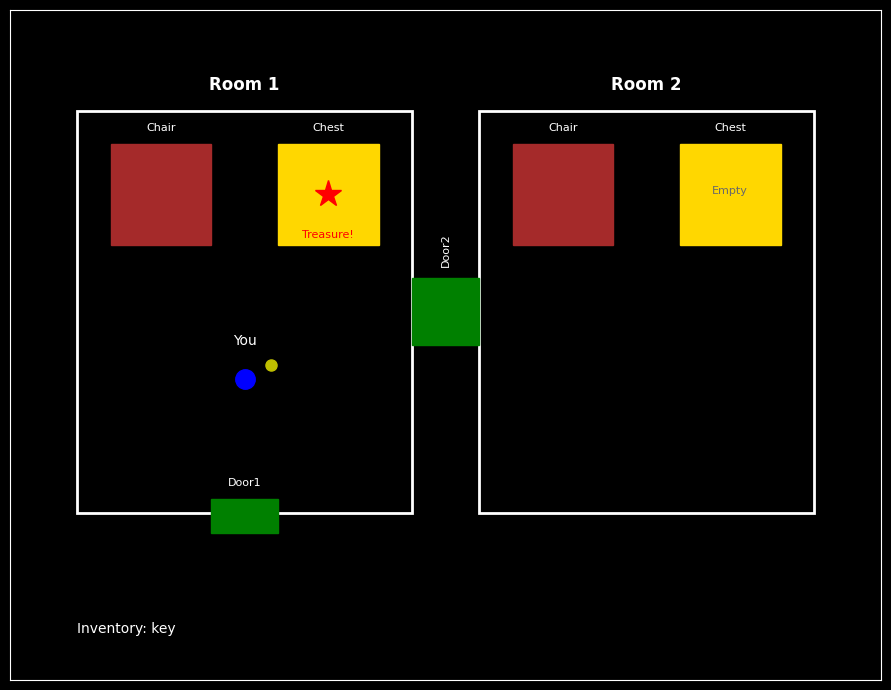

In [51]:
run_intent({"intent": "open", "slots": {"object": "chest", "tool": "key"}})